In [ ]:
import numpy as np
import pandas as pd
import os
import re 
import matplotlib.pyplot as plt
from nilearn.image import new_img_like,load_img,get_data, resample_to_img
from scipy.ndimage import binary_closing
import pandas as pd
from mne_rsa.source_level import rsa_nifti
import mne_rsa


In [ ]:
#requires restricted data available upon request
read_file = pd.read_excel('./fmri_map_id.xlsx')
subjects = list(read_file['BIDS_ID'])


df_ma = pd.read_excel('./MATERIAL.xlsx')
id_2_dur=dict(zip(df_ma['TrialID'],df_ma['soundDur']))


trail_list = [ str(df_ma['word1'][i]) + ' ' + str(df_ma['word2'][i]) + ' '  + str(df_ma['word3'][i]) + ' ' + str(df_ma['word4'][i]) + ' '   
              + str(df_ma['word5'][i]) + ' '   + str(df_ma['word6'][i]) + ' '   + str(df_ma['word7'][i]) + ' '   + str(df_ma['word8'][i])
               for i in range(len(df_ma))]
trail_list = [sentence.replace("nan", "").strip() for sentence in trail_list]


def remove_duplicates(sentence):
    words = sentence.split() 
    for i in range(7):
        if words[-1] ==words[-2]:
            words.pop(-1)
    return ' '.join(words)  


new_list_raw = [remove_duplicates(sentence) for sentence in trail_list]

id_2_trail_type = dict(zip(list(df_ma['TrialID']),new_list_raw))



file_path = './text/all_sentences.txt'


with open(file_path, 'r', encoding='utf-8') as file:
    lines = file.readlines()


item_listxt = [line.strip() for line in lines]


mapping = {}
new_list_co = []
new_list_unc = []
for n_num,co in enumerate(new_list_raw):
    if co in item_listxt:
        new_list_co.append(co)
        mapping[n_num] = len(new_list_co) - 1 
    else:
        new_list_unc.append(co)
        mapping[n_num] = 144 + len(new_list_unc) - 1

new_list = new_list_co + new_list_unc
count_dict = {}
count_new_list = []


for sentence in new_list:
    if sentence in count_dict:
        
        count_dict[sentence] += 1
    else:

        count_dict[sentence] = 0
    

    count_new_list.append(f"{sentence} {count_dict[sentence]}")

In [ ]:
gc_model_rdm_layers = []
for i in range(1,3):
    gpt_array = np.load(f'./numpy_array/rsa/pf_np/acountnum_acc_095_layer{i}_reprensent_on_288.npy')
    print(gpt_array.shape)
    model_rdm_layer = mne_rsa.compute_rdm(gpt_array, metric='cosine')
    mne_rsa.plot_rdms(model_rdm_layer,
                       f"GPT-PF_layer{i}"
                       )
    gc_model_rdm_layers.append(model_rdm_layer)
    print("RDM shape:", model_rdm_layer.shape)

In [ ]:
cla_model_rdm_layers = []
for i in range(1,3):
  
    gpt_array = np.load(f'./numpy_array/rsa/feedback_np/acc_100_layer{i}_reprensent_on_288.npy')

    print(gpt_array.shape)
    model_rdm_layer = mne_rsa.compute_rdm(gpt_array, metric='cosine')#euclidean
    mne_rsa.plot_rdms(model_rdm_layer,
                       f"GPT-F_layer{i}"
                       )
    cla_model_rdm_layers.append(model_rdm_layer)

    print("RDM shape:", model_rdm_layer.shape)

In [ ]:
pre_model_rdm_layers = []
for i in range(1, 3):
    gpt_array = np.load(f'./numpy_array/rsa/prediction_np/acc_097_layer{i}_reprensent_on_288.npy')
    model_rdm_layer = mne_rsa.compute_rdm(gpt_array, metric='cosine')
    mne_rsa.plot_rdms(model_rdm_layer, f"GPT-P_layer{i}")
    pre_model_rdm_layers.append(model_rdm_layer)
    print("RDM shape:", model_rdm_layer.shape)

In [ ]:
blank_model_rdm_layers = []
for i in range(1, 3):
   
    gpt_array = np.load(f'./numpy_array/rsa/blank_version_gpt/blank_layer{i}_reprensent_on_288.npy')

    model_rdm_layer = mne_rsa.compute_rdm(gpt_array, metric='cosine')
    mne_rsa.plot_rdms(model_rdm_layer, f"GPT-blakk_layer{i}")
    blank_model_rdm_layers.append(model_rdm_layer)

    print("RDM shape:", model_rdm_layer.shape)

In [ ]:
length_rdm =mne_rsa.compute_rdm(np.load('./numpy_array/rsa/length.npy'),metric='euclidean')
mne_rsa.plot_rdms(length_rdm)
print("RDM shape:",length_rdm.shape)

In [ ]:
type_rdm =mne_rsa.compute_rdm(np.load('./numpy_array/rsa/block.npy'),metric='hamming')
mne_rsa.plot_rdms(type_rdm)
print("RDM shape:",type_rdm.shape) 

## rsa

In [ ]:
rsa_map_path = ''

In [ ]:
def process_subject(subject, layer_index, gc_model_rdm_layers, pre_model_rdm_layers, cla_model_rdm_layers, blank_model_rdm_layers, count_new_list):
    new_rdm_used = []
    new_rdm_used.append(gc_model_rdm_layers[layer_index])
    new_rdm_used.append(pre_model_rdm_layers[layer_index])
    new_rdm_used.append(cla_model_rdm_layers[layer_index])
    new_rdm_used.append(blank_model_rdm_layers[layer_index])
    new_rdm_used.append(length_rdm)
    new_rdm_used.append(type_rdm)

    folder_path = f'./tmap/LSS_single/sub-{subject}/'
    file_names = os.listdir(folder_path)

    contrast_name = []
    for file_name in file_names:
        if file_name.endswith('.nii.gz'):
            start_index = file_name.find('con-') + len('con-')
            end_index = file_name.find('.nii.gz')
            content = file_name[start_index:end_index]
            contrast_name.append(content)


    sorted_contrast_name = [item for item in count_new_list if item in contrast_name]
    if len(sorted_contrast_name) != len(new_list):
        print(f"Subject {subject}: lack items!!")

    img_list = []
    for con in sorted_contrast_name:
        pattern = re.compile(f'sub-{subject}_(.*?)_con-{con}.nii.gz')
        matched_files = [file_name for file_name in file_names if pattern.match(file_name)]
        img_list.extend(matched_files)

    # Load gray matter image
    if str(subject)[:2] == '22':
        gray_img = load_img(f"./bids_data_22/derivatives/sub-{subject}/anat/sub-{subject}_desc-brain_mask.nii.gz")
    elif str(subject)[:2] == '23':
        gray_img = load_img(f"./BIDS_data/derivatives/sub-{subject}/anat/sub-{subject}_desc-brain_mask.nii.gz")
    elif str(subject)[:2] == '24':
        gray_img = load_img(f"./bids_data_24/derivatives/sub-{subject}/anat/sub-{subject}_desc-brain_mask.nii.gz")

    gm_target_data = get_data(gray_img)
    gm_target_mask = (gm_target_data > 0.2).astype("int8")
    gm_target_mask = binary_closing(gm_target_mask, iterations=2)
    gray_mask = new_img_like(gray_img, gm_target_mask)

    # Load functional image
    if str(subject)[:2] == '22':
        resample_target_img = load_img(f"./bids_data_22/derivatives/sub-{subject}/func/sub-{subject}_task-bctnpvp_run-01_space-T1w_desc-preproc_bold.nii.gz")
    elif str(subject)[:2] == '23':
        resample_target_img = load_img(f"./BIDS_data/derivatives/sub-{subject}/func/sub-{subject}_task-bctnpvp_run-01_space-T1w_desc-preproc_bold.nii.gz")
    elif str(subject)[:2] == '24':
        resample_target_img = load_img(f"./bids_data_24/derivatives/sub-{subject}/func/sub-{subject}_task-bctnpvp_run-01_space-T1w_desc-preproc_bold.nii.gz")

    gray_mask = resample_to_img(gray_mask, resample_target_img, interpolation="nearest")
    x, y, z = gray_mask.shape
    data = np.zeros((len(img_list), x, y, z))
    
    for i, im in enumerate(img_list):
        data[i] = load_img(folder_path + im).get_fdata()

    data_final = new_img_like(resample_target_img, np.transpose(data, (1, 2, 3, 0)))

    result = rsa_nifti(data_final,
                       rdm_model=new_rdm_used,
                       spatial_radius=0.01,
                       image_rdm_metric='euclidean',
                       rsa_metric='regression',
                       brain_mask=gray_mask,
                       verbose=True,
                       n_jobs=7,
                       ignore_nan=True)
    output_folder0 = rsa_map_path + f'accountnum_pc_reg_layer_{layer_index}/sub-{subject}/'
    os.makedirs(output_folder0, exist_ok=True)
    result[0].to_filename(f'{output_folder0}/sub-{subject}_space-T1w_RSA.nii.gz')

    output_folder1 =rsa_map_path + f'accountnum_pre_reg_layer_{layer_index}/sub-{subject}/'
    os.makedirs(output_folder1, exist_ok=True)
    result[1].to_filename(f'{output_folder1}/sub-{subject}_space-T1w_RSA.nii.gz')

    output_folder2 = rsa_map_path + f'accountnum_cla_reg_layer_{layer_index}/sub-{subject}/'
    os.makedirs(output_folder2, exist_ok=True)
    result[2].to_filename(f'{output_folder2}/sub-{subject}_space-T1w_RSA.nii.gz')

    output_folder3 = rsa_map_path + f'accountnum_blank_reg_layer_{layer_index}/sub-{subject}/'
    os.makedirs(output_folder3, exist_ok=True)
    result[3].to_filename(f'{output_folder3}/sub-{subject}_space-T1w_RSA.nii.gz')

    output_folder4 = rsa_map_path + f'accountnum_length_reg_layer_{layer_index}/sub-{subject}/'
    os.makedirs(output_folder4, exist_ok=True)
    result[4].to_filename(f'{output_folder4}/sub-{subject}_space-T1w_RSA.nii.gz')

    output_folder5 = rsa_map_path + f'accountnum_type_reg_layer_{layer_index}/sub-{subject}/'
    os.makedirs(output_folder5, exist_ok=True)
    result[5].to_filename(f'{output_folder5}/sub-{subject}_space-T1w_RSA.nii.gz')


In [ ]:
from joblib import Parallel, delayed


# 并行执行
for layer_index in range(1, 3):
    Parallel(n_jobs=34)(
        delayed(process_subject)(subject, layer_index, gc_model_rdm_layers, pre_model_rdm_layers, cla_model_rdm_layers, blank_model_rdm_layers, count_new_list)
        for subject in subjects
    )


## to_mni

In [ ]:
import ants
import pandas as pd
from multiprocessing import Pool

read_file = pd.read_excel('./fmri_map_id.xlsx')
subjects = list(read_file['BIDS_ID'])
pro_names = ['pc', 'pre', 'cla']

def process_subject(subject, layer_index, pro_name):
    print(subject,' started')
    sub_name = subject  # You should define your subject name or get it from some context.

    if str(subject)[:2] == '22':
        ref_file = f"./bids_data_22/derivatives/sub-{subject}/anat/sub-{subject}_space-MNI152NLin6Asym_desc-preproc_T1w.nii.gz"
    if str(subject)[:2] == '23':
        ref_file = f"./BIDS_data/derivatives/sub-{subject}/anat/sub-{subject}_space-MNI152NLin6Asym_desc-preproc_T1w.nii.gz"
    if str(subject)[:2] == '24':
        ref_file = f"./bids_data_24/derivatives/sub-{subject}/anat/sub-{subject}_space-MNI152NLin6Asym_desc-preproc_T1w.nii.gz"

    if str(subject)[:2] == '22':
        trans_file = f"./bids_data_22/derivatives/sub-{subject}/anat/sub-{subject}_from-T1w_to-MNI152NLin6Asym_mode-image_xfm.h5"
    if str(subject)[:2] == '23':
        trans_file = f"./BIDS_data/derivatives/sub-{subject}/anat/sub-{subject}_from-T1w_to-MNI152NLin6Asym_mode-image_xfm.h5"
    if str(subject)[:2] == '24':
        trans_file = f"./bids_data_24/derivatives/sub-{subject}/anat/sub-{subject}_from-T1w_to-MNI152NLin6Asym_mode-image_xfm.h5"



  
    RSA_file = f'{rsa_map_path}accountnum_{pro_name}_reg_layer_{layer_index}/sub-{subject}/sub-{subject}_space-T1w_RSA.nii.gz'

    reference_image = ants.image_read(ref_file)


    input_image = ants.image_read(RSA_file)

    transformed_image = ants.apply_transforms(fixed=reference_image, moving=input_image,
                                                transformlist=trans_file, interpolator="bSpline")
    target_spacing = (3.0, 3.0, 3.0)
    resampled_fixed_image = ants.resample_image(transformed_image, target_spacing,
         use_voxels=False, interp_type=4)
    output_filename = RSA_file.replace("T1w_RSA.nii.gz", "MNI152NLin6Asym_RSA.nii.gz")#MNI152NLin6Asym"MNI152NLin2009Asym_RSA.nii.gz"
    ants.image_write(resampled_fixed_image, output_filename)
  
for pro_name in pro_names:
    for layer_index in range(1, 3):
        with Pool(processes=34) as pool:
            pool.starmap(process_subject, [(subject, layer_index,pro_name) for subject in subjects])


## tfce

In [ ]:
import pandas as pd
from nilearn.image import  load_img
import nilearn

read_file = pd.read_excel('./fmri_map_id.xlsx')
subjects = list(read_file['BIDS_ID'])
layers = 2
pro_names = ['pre','cla','pc',  'blank', 'length', 'type']
design_matrix = pd.DataFrame([1] * len(subjects), columns=["intercept"])
mask = load_img('./tpl-MNI152NLin6Asym_res-02_desc-brain_mask.nii.gz')

In [ ]:
for p_name in pro_names:
    for layer_index in range(1,layers+1):
        cmap_filenames = []
        
        root_data_path = rsa_map_path
        for subject in subjects:    
            
            cmap_filenames.append(
                load_img(root_data_path + f'accountnum_{p_name}_reg_layer_{layer_index}/sub-{subject}/sub-{subject}_space-MNI152NLin6Asym_RSA.nii.gz')
            )

        tfce_cor_sec = nilearn.glm.second_level.non_parametric_inference(
                        cmap_filenames,
                        design_matrix=design_matrix,
                        n_jobs=-1,
                        n_perm=10000,
                        mask = mask,
                        tfce=True,
                        verbose = 1
                    )
        save_dir = './tfce_maps/'
        os.makedirs(save_dir, exist_ok=True)   
        tfce_cor_sec['logp_max_tfce'].to_filename(save_dir + f'z_map_accountnum_{p_name}_reg_layer={layer_index}.nii')


## plot_rsa

In [6]:
from matplotlib.colors import LinearSegmentedColormap
from nilearn import plotting
threshold = -np.log10(0.05)  #fwe-5% corrected
vmax = 4
tfce_maps = './tfce_maps/'


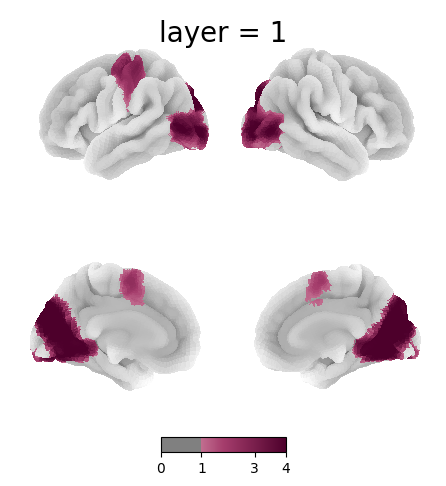

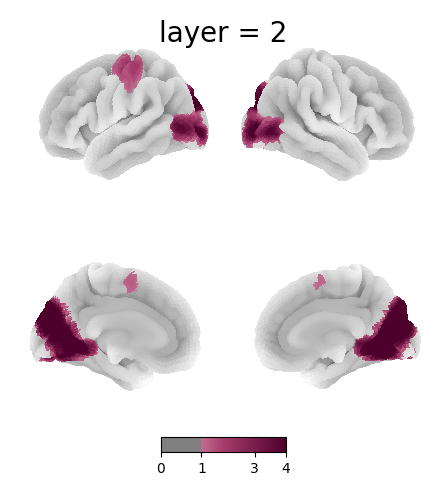

In [ ]:
for layer_index in range(1,3):
    
    thresholded_map=load_img(f'{tfce_maps}z_map_accountnum_pc_reg_layer={layer_index}.nii')
    colors = ['#F5C6D0', '#A53D6C', '#4D002B']
    custom_cmap = LinearSegmentedColormap.from_list('custom_cmap', colors)

    
    plotting.plot_img_on_surf(thresholded_map,
                            surf_mesh='fsaverage5',
                            views=['lateral', 'medial'],
                            hemispheres=['left', 'right'],
                            cmap=custom_cmap,  
                            threshold=threshold,
                            vmax=vmax,
                            )
    plt.suptitle(f"layer = {layer_index}", fontsize=20)
    plt.show()
    

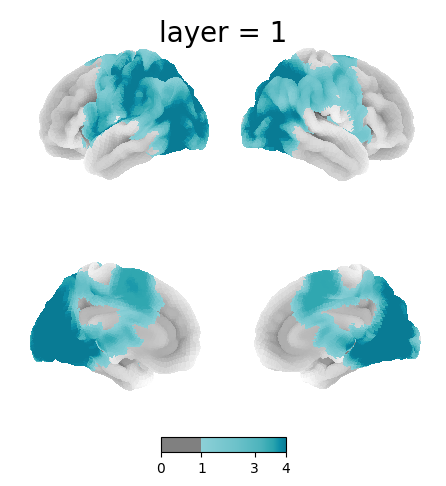

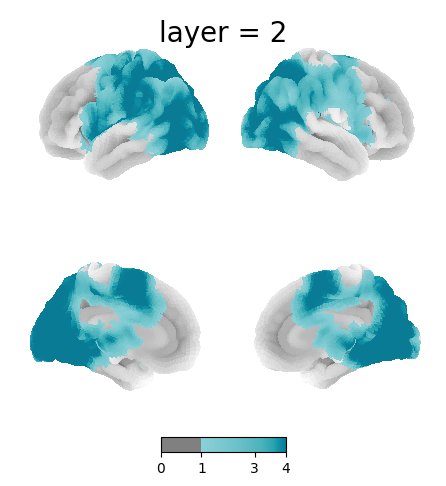

In [8]:
for layer_index in range(1,3):
    
    thresholded_map=load_img(f'{tfce_maps}/z_map_accountnum_pre_reg_layer={layer_index}.nii')
    colors = ['#B2E0E6', '#8FD1D8', '#6DC2CA', '#4CB3BC', '#2AA4AE', '#0D8FA8', '#0B859E', '#097B94']

    positions = [0.0, 0.3, 0.6, 0.8, 0.9, 0.95, 0.975, 1.0]

    custom_cmap = LinearSegmentedColormap.from_list('custom_cmap', list(zip(positions, colors)))
    
    plotting.plot_img_on_surf(thresholded_map,
                            surf_mesh='fsaverage5',
                            views=['lateral', 'medial'],
                            hemispheres=['left', 'right'],
                            cmap=custom_cmap,  
                           
                            threshold=threshold,
                            vmax=vmax,
                           
                            )
    plt.suptitle(f"layer = {layer_index}", fontsize=20)
    plt.show()    

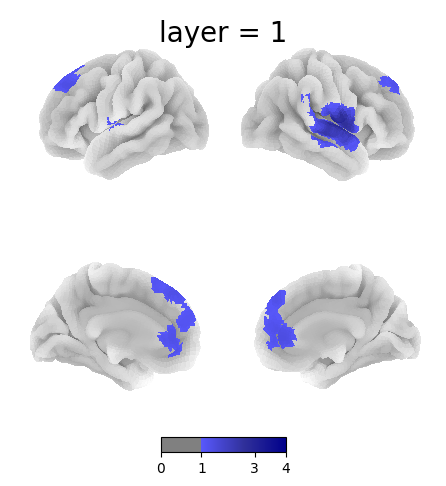

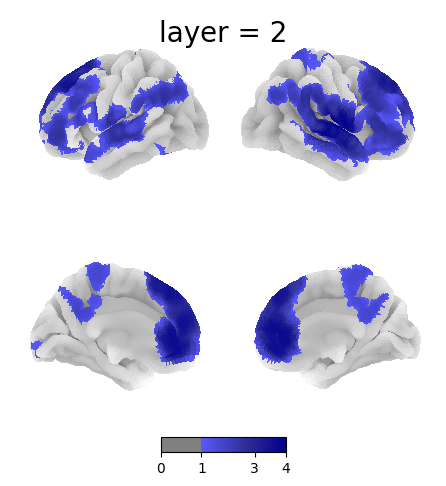

In [9]:
for layer_index in range(1,3):
    
    thresholded_map=load_img(f'{tfce_maps}z_map_accountnum_cla_reg_layer={layer_index}.nii')
 
    colors = [ '#7090D2', '#5757F9', '#30309A', '#00008B']
    custom_cmap = LinearSegmentedColormap.from_list('custom_cmap', colors)

    
    plotting.plot_img_on_surf(thresholded_map,
                            surf_mesh='fsaverage5',
                            views=['lateral', 'medial'],
                            hemispheres=['left', 'right'],
                            cmap=custom_cmap, 
                            threshold=threshold,
                            vmax=vmax,
                            )
    plt.suptitle(f"layer = {layer_index}", fontsize=20)
    plt.show()

    